## โจทย์ข้อที่ 1: การเตรียมข้อมูลและการสเกล (Data Preparation & Scaling)
1. โหลดชุดข้อมูล Breast Cancer Dataset จาก sklearn.datasets.load_breast_cancer
2. แบ่งข้อมูลออกเป็น Training set (70%) และ Test set (30%) โดยกำหนด random_state=42 และใช้ stratify=y เพื่อรักษาสัดส่วนของคลาส
3. ทำ Feature Scaling บนข้อมูลด้วย StandardScaler จาก sklearn.preprocessing โดยทำการ Fit และ Transform บน Training set แล้วนำไป Transform บน Test set

In [5]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [8]:
# step 1 
breast = load_breast_cancer()
x = breast.data
y = breast.target

# step 2 
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.7, random_state=42, stratify=y)

# step 3 
st = StandardScaler()
train_scaler = st.fit_transform(x_train)
test_scaler = st.fit_transform(x_test)

## โจทย์ข้อที่ 2: การทดลองผลกระทบของค่า C (Soft Margin vs Hard Margin)
1. สร้างโมเดล SVC โดยกำหนดให้ใช้ kernel='linear'
2. ทดลองปรับค่าพารามิเตอร์ C เป็น 3 ระดับ ได้แก่:
    - C = 0.001
    - C = 1.0,
    - C = 100.0
3. เทรนโมเดลด้วยข้อมูล Training set ที่ผ่านการ Scaling แล้ว
4. วัดและบันทึกค่าความถูกต้อง (Accuracy Score) บน Test set ของแต่ละค่า C ลงในตารางบันทึกผล
5. ดูลักษณะของ margin สูตร $$\text{Margin Width} = \frac{2}{\Vert{}w\Vert{}}$$
   - หา L2-norm ของ w: ||w||
   - คำนวณความกว้างของ Margin: 2 / ||w||

In [19]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np

In [20]:
c_list = [0.001, 1.0, 100.0]
acc = []
w_norms = []
margin_widths = []

for i in c_list:
    # step 1 , 2
    svm = SVC(random_state=42, kernel='linear',C = i)

    # step 3 
    svm.fit(train_scaler, y_train)
    y_pred = svm.predict(test_scaler)

    # step 4 
    acc1 = accuracy_score(y_test, y_pred)
    acc.append(acc1)

    # step 5.1
    w_norm = np.linalg.norm(svm.coef_)
    w_norms.append(w_norm)

    # step 5.2 
    margin = 2 / w_norm
    margin_widths.append(margin)

df_results = pd.DataFrame({'C': c_list, 'Accuracy': acc, 'W_Norm': w_norms, 'Margin_width': margin_widths})
df_results

,C,Accuracy,W_Norm,Margin_width
0,0.001,0.941520,0.310449,6.442286
1,1.000,0.964912,2.653155,0.753820
2,100.000,0.912281,24.511660,0.081594


## โจทย์ข้อที่ 3: การเปรียบเทียบประสิทธิภาพของ Kernel ชนิดต่างๆ
1. เปรียบเทียบประสิทธิภาพของโมเดล SVC บนชุดข้อมูล Breast Cancer โดยทดลองใช้ Kernel 3 รูปแบบ (กำหนด C = 1.0)
   - Linear Kernel: kernel='linear'
   - Polynomial Kernel: kernel='poly', degree=3
   - RBF Kernel: kernel='rbf', gamma='scale'
2. วัดค่า Accuracy บน Test set และบันทึกผลการทดลองลงในตารางบันทึกผล

In [23]:
# step 1.1
linear = SVC(random_state=42, C = 1.0, kernel = 'linear')
linear.fit(train_scaler, y_train)
y_pred_linear = linear.predict(test_scaler)

# step 1.2 
poly = SVC(random_state = 42, C = 1.0, kernel = 'poly', degree = 3)
poly.fit(train_scaler, y_train)
y_pred_poly = poly.predict(test_scaler)

# step 1.3 
rbf = SVC(random_state=42, C=1.0, kernel='rbf', gamma='scale')
rbf.fit(train_scaler, y_train)
y_pred_rbf = rbf.predict(test_scaler)

# step 2
list_acc = []
list_acc.append(accuracy_score(y_test, y_pred_linear))
list_acc.append(accuracy_score(y_test, y_pred_poly))
list_acc.append(accuracy_score(y_test, y_pred_rbf))

kernels = ['linear', 'Polynomial', 'RBF']
df_results = pd.DataFrame({
    'Kernel': kernels,
    'Accuracy': list_acc
})
df_results

,Kernel,Accuracy
0,linear,0.964912
1,Polynomial,0.906433
2,RBF,0.976608


## โจทย์ข้อที่ 4: การสร้างและแสดงภาพ Decision Boundary (Visualization)
1. โหลดชุดข้อมูล Iris Dataset (load_iris) และเลือกใช้เฉพาะ 2 ฟีเจอร์แรก (Sepal length และ Sepal width) เพื่อให้สามารถสร้างกราฟ 2 มิติได้
2. สร้างและเทรนโมเดล SVC จำนวน 2 โมเดล ได้แก่:
   - โมเดล A: kernel='linear', C=1.0
   - โมเดล B: kernel='rbf', C=1.0, gamma='scale'
3. เขียนโปรแกรมวาดกราฟ Decision Boundary เปรียบเทียบความแตกต่างระหว่างเส้นแบ่งแบบตรง (Linear) และเส้นแบ่งแบบโค้ง (RBF)
   - สร้าง Meshgrid เพื่อคำนวณพื้นที่ Decision Boundary
   - สุ่มจุดพิกัดถี่ๆ (step = 0.02)
   - วาดกราฟเปรียบเทียบ
   - ทำนายคลาสของทุกๆ จุดใน Meshgrid
   - วาดสีพื้นหลัง (Decision Boundary)
   - วาดจุดข้อมูลจริง (Scatter Plot)

In [28]:
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

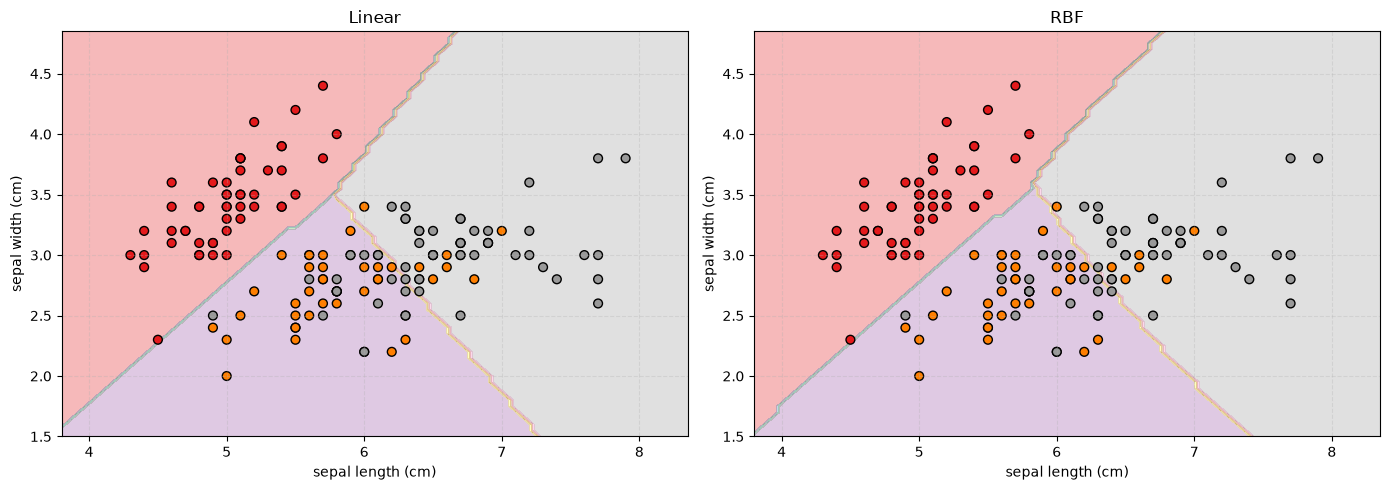

In [34]:
# step 1
rs = load_iris()
x = rs.data[:, :2]
y = rs.target
feature = rs.feature_names[:2]
x_train1, x_test1, y_train1, y_test1 = train_test_split(x, y, test_size=0.3, random_state=42)

# step 2.1
linear2 = SVC(random_state=42, C=1.0, kernel='linear')
linear2.fit(x_train1, y_train1)

# step 2.2
rbf2 = SVC(random_state=42, C=1.0, gamma='scale')
rbf2.fit(x_train1, y_train1)

# step 3.1
x_min, x_max = x[:, 0].min() - 0.5, x[:, 0].max() + 0.5
y_min, y_max = x[:, 1].min() - 0.5, x[:, 1].max() + 0.5

# step 3.2 
xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.05),
    np.arange(y_min, y_max, 0.05)
)

# step 3.3 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = [('Linear', linear2), ('RBF', rbf2)]

for ax, (title, model) in zip(axes, models):
    # step 3.4
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # step 3.5
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Set1)

    # step 3.6
    scatter = ax.scatter(x[:, 0], x[:, 1], c=y, cmap=plt.cm.Set1, edgecolor='k', s=40)

    ax.set_title(title, fontsize=12)
    ax.set_xlabel(rs.feature_names[0])
    ax.set_ylabel(rs.feature_names[1])
    ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()